# TAREA COMPLEMENTARIA - APRENDIZAJE SUPERVISADO
# Predicción de Renuncia de Empleados
# Matías Aldaz -7308


In [ ]:
# =============================================================================

# ── INSTALACIÓN ──
# !pip install xgboost scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
from xgboost import XGBClassifier

np.random.seed(42)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

1. CREACIÓN DEL DATASET CON LÓGICA COHERENTE

In [ ]:
# =============================================================================
# REGLAS DE COHERENCIA IMPLEMENTADAS:
#  R1: Baja satisfacción (1-2) + muchas horas extra → mayor probabilidad de renuncia
#  R2: Sin ascenso en 2 años + evaluación alta → frustración → más renuncia
#  R3: Salario bajo para antigüedad alta → renuncia probable
#  R4: Distancia larga + horas extra altas → renuncia probable
#  R5: Pocas capacitaciones + poca satisfacción → renuncia probable
#  R6: Edad coherente con años_en_empresa (no tener 25 años y 20 en empresa)

N = 350  # mínimo 300 registros

# ── Variables base ──
edad = np.random.randint(22, 61, N)
# años en empresa: máximo (edad - 22) para que sea coherente
anos_en_empresa = np.array([np.random.randint(0, min(21, e - 21)) for e in edad])

# Puestos y salarios coherentes con antigüedad
def salario_base(anos):
    if anos <= 2:   return np.random.randint(800, 1200)
    elif anos <= 5: return np.random.randint(1200, 2000)
    elif anos <= 10:return np.random.randint(2000, 3500)
    else:           return np.random.randint(3500, 6000)

salario_mensual = np.array([salario_base(a) for a in anos_en_empresa])

horas_extra_semana     = np.random.randint(0, 21, N)
satisfaccion_laboral   = np.random.randint(1, 6, N)
num_proyectos_ano      = np.random.randint(1, 11, N)
distancia_casa_trabajo = np.random.randint(1, 81, N)
ultima_evaluacion      = np.round(np.random.uniform(0.3, 1.0, N), 2)
capacitaciones         = np.random.randint(0, 6, N)
tiene_ascenso          = np.random.binomial(1, 0.25, N)  # 25% tuvo ascenso

# ── Cálculo de probabilidad de renuncia con lógica de negocio ──
prob_renuncia = np.zeros(N)

# R1: Baja satisfacción + muchas horas extra
prob_renuncia += (5 - satisfaccion_laboral) / 4 * 0.30
prob_renuncia += (horas_extra_semana / 20) * 0.15

# R2: Sin ascenso + buena evaluación = frustración
sin_ascenso = 1 - tiene_ascenso
prob_renuncia += sin_ascenso * ultima_evaluacion * 0.20

# R3: Salario bajo para su antigüedad
salario_esperado = np.array([salario_base(a) for a in anos_en_empresa])
salario_relativo = salario_mensual / (salario_esperado + 1)
prob_renuncia += (1 - np.clip(salario_relativo, 0, 1)) * 0.15

# R4: Distancia larga + horas extra
prob_renuncia += (distancia_casa_trabajo / 80) * (horas_extra_semana / 20) * 0.10

# R5: Pocas capacitaciones
prob_renuncia += (1 - capacitaciones / 5) * 0.10

# Normalizar entre 0 y 1
prob_renuncia = np.clip(prob_renuncia, 0, 1)

# Generar variable objetivo
renuncia = np.array([np.random.binomial(1, p) for p in prob_renuncia])

# ── Ensamblar DataFrame ──
df = pd.DataFrame({
    'edad': edad,
    'anos_en_empresa': anos_en_empresa,
    'salario_mensual': salario_mensual,
    'horas_extra_semana': horas_extra_semana,
    'satisfaccion_laboral': satisfaccion_laboral,
    'num_proyectos_ano': num_proyectos_ano,
    'distancia_casa_trabajo_km': distancia_casa_trabajo,
    'ultima_evaluacion_desempeno': ultima_evaluacion,
    'capacitaciones_recibidas': capacitaciones,
    'tiene_ascenso_ultimos_2_anos': tiene_ascenso,
    'renuncia': renuncia
})

print("=" * 60)
print("DATASET CREADO EXITOSAMENTE")
print("=" * 60)
print(f"Total registros: {len(df)}")
print(f"Renuncias (1): {renuncia.sum()} ({renuncia.mean()*100:.1f}%)")
print(f"Se quedaron (0): {(renuncia == 0).sum()} ({(1-renuncia.mean())*100:.1f}%)")
print("\nPrimeros 5 registros:")
print(df.head())

DATASET CREADO EXITOSAMENTE
Total registros: 350
Renuncias (1): 136 (38.9%)
Se quedaron (0): 214 (61.1%)

Primeros 5 registros:
   edad  anos_en_empresa  salario_mensual  horas_extra_semana  \
0    60                5             1966                  11   
1    50               12             4752                  11   
2    36                3             1777                   3   
3    29                5             1274                  15   
4    42               14             3934                   3   

   satisfaccion_laboral  num_proyectos_ano  distancia_casa_trabajo_km  \
0                     4                  8                          3   
1                     2                  4                         70   
2                     5                  5                          2   
3                     1                  4                         44   
4                     1                  4                          2   

   ultima_evaluacion_desempeno  capacitaci

2. ANÁLISIS EXPLORATORIO (EDA)


ESTADÍSTICAS DESCRIPTIVAS
                              count     mean      std    min      25%      50%      75%     max
edad                          350.0    41.78    11.57   22.0    32.00    43.00    52.00    60.0
anos_en_empresa               350.0     7.29     6.21    0.0     2.00     5.00    12.00    20.0
salario_mensual               350.0  2639.67  1668.04  802.0  1120.25  1971.00  4051.25  5972.0
horas_extra_semana            350.0    10.27     6.18    0.0     5.00    10.00    16.00    20.0
satisfaccion_laboral          350.0     3.01     1.41    1.0     2.00     3.00     4.00     5.0
num_proyectos_ano             350.0     5.51     2.90    1.0     3.00     5.00     8.00    10.0
distancia_casa_trabajo_km     350.0    36.49    23.28    1.0    16.00    32.00    57.50    80.0
ultima_evaluacion_desempeno   350.0     0.64     0.21    0.3     0.46     0.64     0.83     1.0
capacitaciones_recibidas      350.0     2.50     1.68    0.0     1.00     3.00     4.00     5.0
tiene_ascenso

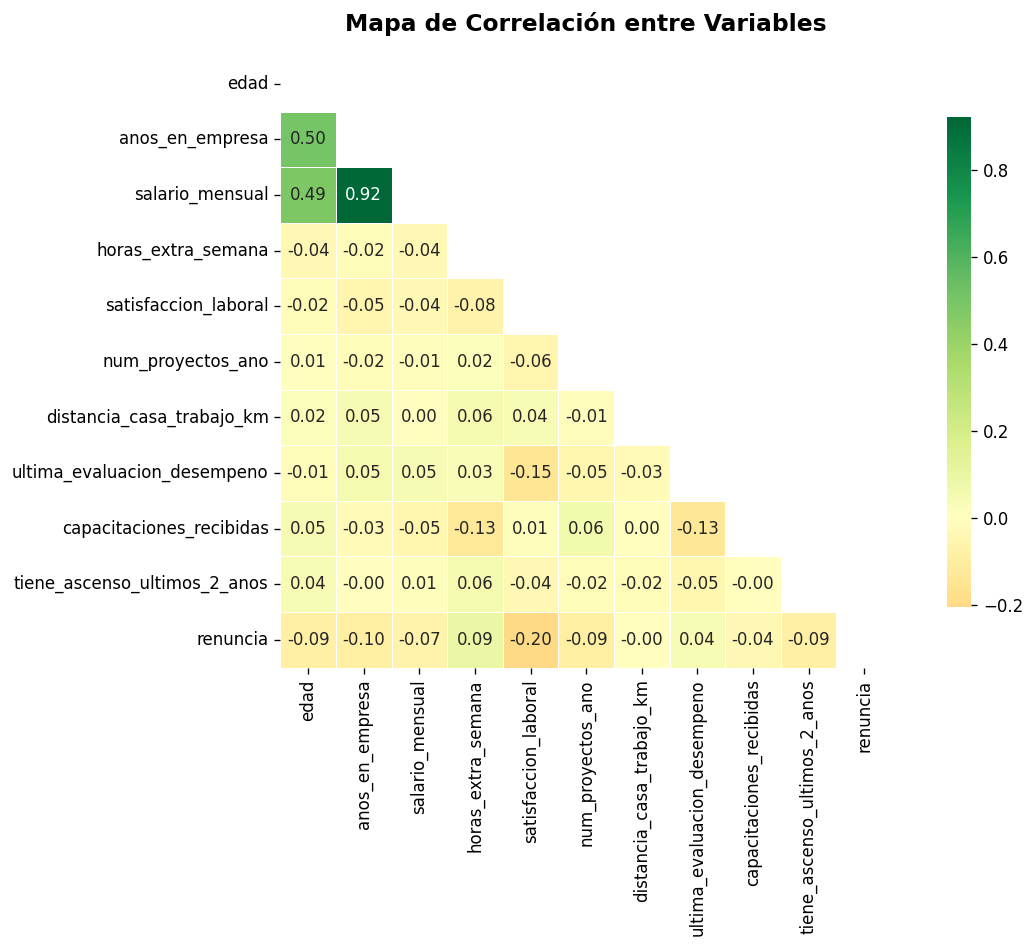


Top 3 correlaciones con 'renuncia':
satisfaccion_laboral    0.204226
anos_en_empresa         0.097370
num_proyectos_ano       0.090874
Name: renuncia, dtype: float64


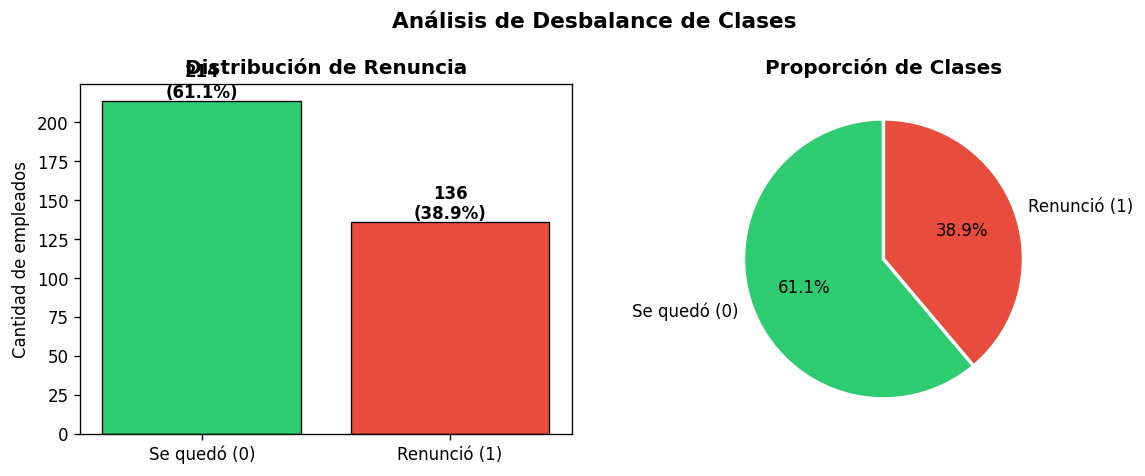

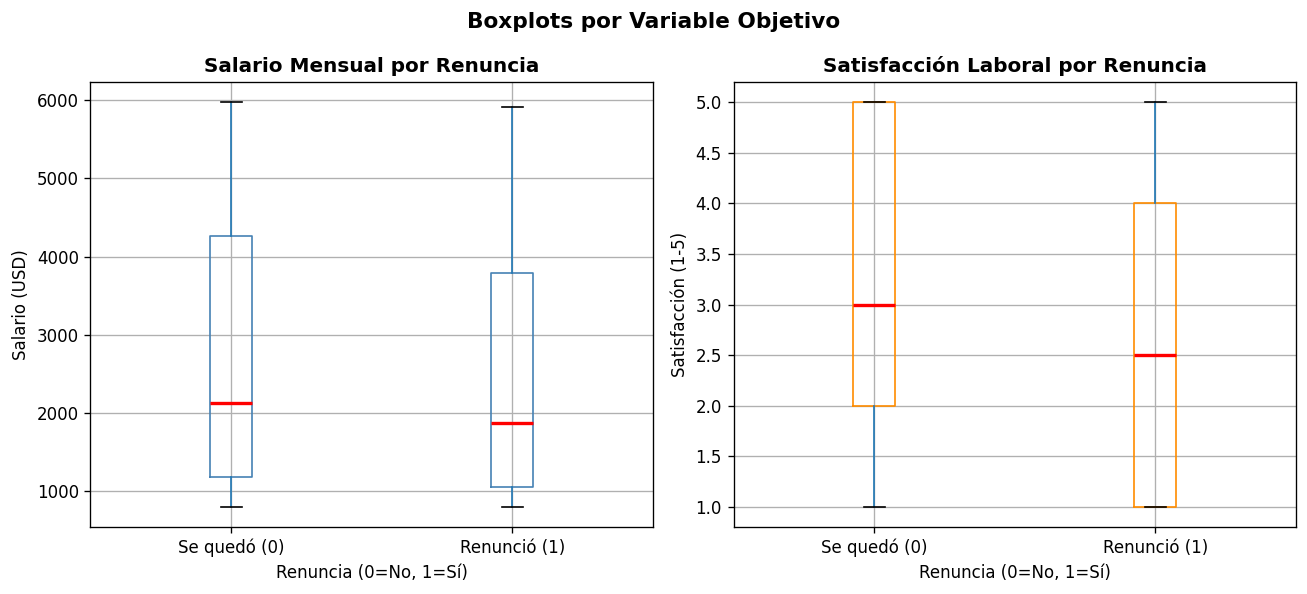

In [ ]:
# =============================================================================
import os

# Create the output directory if it doesn't exist
output_dir = '/mnt/user-data/outputs/'
os.makedirs(output_dir, exist_ok=True)

# ── 2.1 Estadísticas descriptivas ──
print("\n" + "=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)
print(df.describe().T.round(2).to_string())

# ── 2.2 Heatmap de correlación ──
fig, ax = plt.subplots(figsize=(11, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Mapa de Correlación entre Variables', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'heatmap_correlacion.png'), bbox_inches='tight')
plt.show()

# Top 3 correlaciones con renuncia
corr_renuncia = corr['renuncia'].drop('renuncia').abs().sort_values(ascending=False)
print("\nTop 3 correlaciones con 'renuncia':")
print(corr_renuncia.head(3))

# ── 2.3 Distribución de la variable objetivo ──
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['renuncia'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Se quedó (0)', 'Renunció (1)'], counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Distribución de Renuncia', fontweight='bold')
axes[0].set_ylabel('Cantidad de empleados')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Se quedó (0)', 'Renunció (1)'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de Clases', fontweight='bold')

plt.suptitle('Análisis de Desbalance de Clases', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'distribucion_renuncia.png'), bbox_inches='tight')
plt.show()

# ── 2.4 Boxplots de salario y satisfacción ──
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

df.boxplot(column='salario_mensual', by='renuncia', ax=axes[0],
           boxprops=dict(color='steelblue'), medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Salario Mensual por Renuncia')
axes[0].set_xlabel('Renuncia (0=No, 1=Sí)')
axes[0].set_ylabel('Salario (USD)')
axes[0].set_xticklabels(['Se quedó (0)', 'Renunció (1)'])
plt.sca(axes[0])
plt.title('Salario Mensual por Renuncia', fontweight='bold')

df.boxplot(column='satisfaccion_laboral', by='renuncia', ax=axes[1],
           boxprops=dict(color='darkorange'), medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Satisfacción Laboral por Renuncia')
axes[1].set_xlabel('Renuncia (0=No, 1=Sí)')
axes[1].set_ylabel('Satisfacción (1-5)')
axes[1].set_xticklabels(['Se quedó (0)', 'Renunció (1)'])
plt.sca(axes[1])
plt.title('Satisfacción Laboral por Renuncia', fontweight='bold')

plt.suptitle('Boxplots por Variable Objetivo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'boxplots_eda.png'), bbox_inches='tight')
plt.show()

3. MODELADO - 3 ALGORITMOS


DIVISIÓN DEL DATASET
Train: 280 registros | Test: 70 registros

Regresión Logística:
              precision    recall  f1-score   support

           0       0.64      0.91      0.75        43
           1       0.56      0.19      0.28        27

    accuracy                           0.63        70
   macro avg       0.60      0.55      0.51        70
weighted avg       0.61      0.63      0.57        70


Random Forest:
              precision    recall  f1-score   support

           0       0.63      0.77      0.69        43
           1       0.44      0.30      0.36        27

    accuracy                           0.59        70
   macro avg       0.54      0.53      0.53        70
weighted avg       0.56      0.59      0.56        70


Gradient Boosting:
              precision    recall  f1-score   support

           0       0.67      0.65      0.66        43
           1       0.46      0.48      0.47        27

    accuracy                           0.59        70
   mac

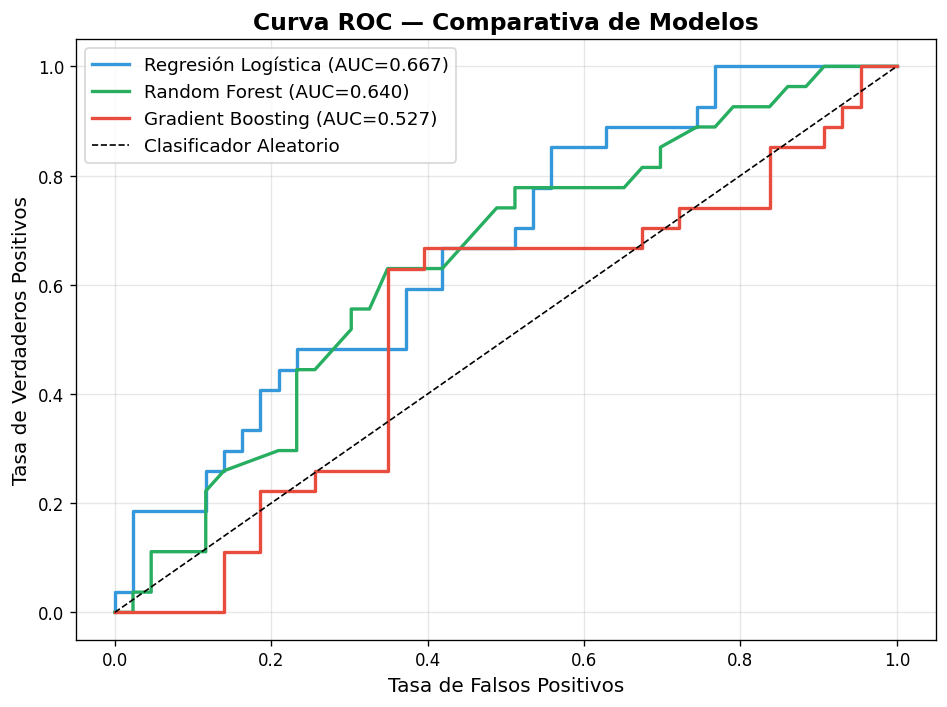

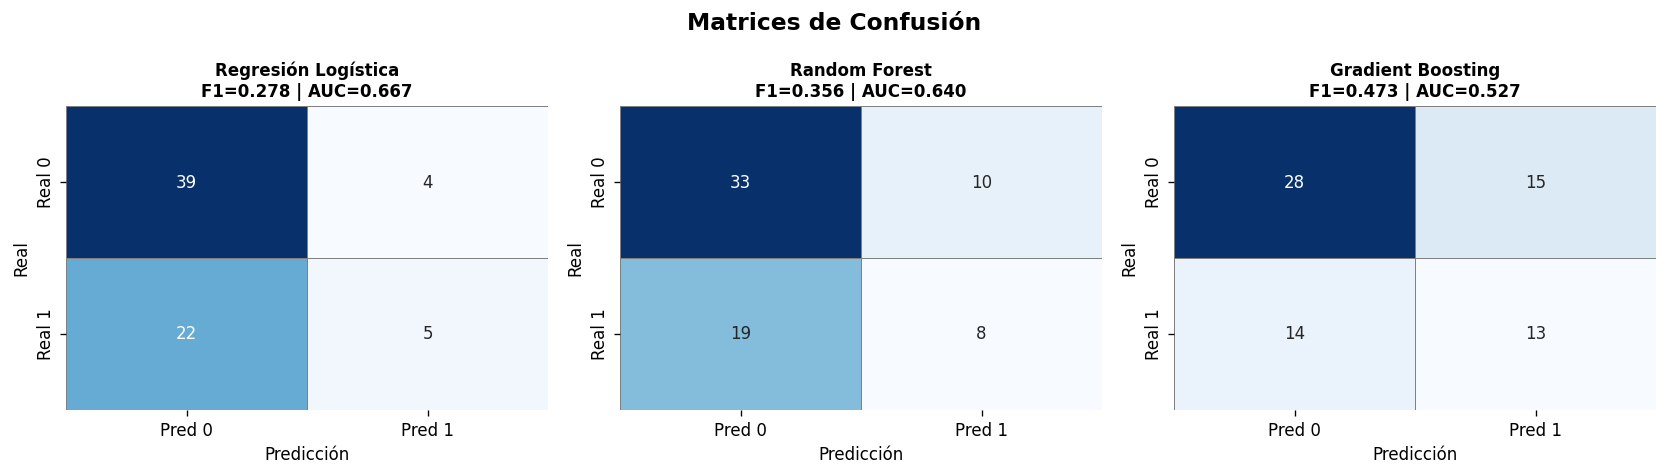

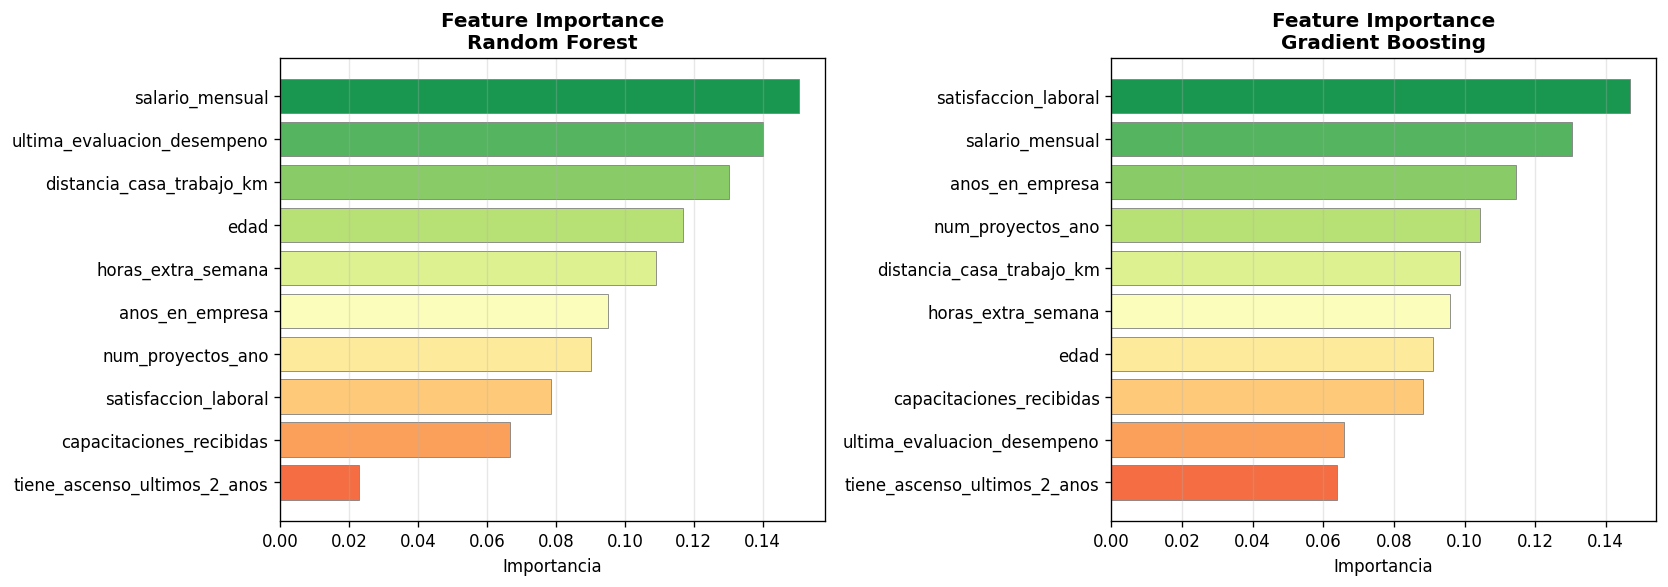

In [ ]:
# =============================================================================

# ── 3.1 Preparación de datos ──
X = df.drop('renuncia', axis=1)
y = df['renuncia']

# División 80/20 con random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# StandardScaler ajustado SOLO sobre entrenamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform sobre train
X_test_scaled  = scaler.transform(X_test)         # solo transform sobre test

print("\n" + "=" * 60)
print("DIVISIÓN DEL DATASET")
print("=" * 60)
print(f"Train: {X_train.shape[0]} registros | Test: {X_test.shape[0]} registros")

# ── 3.2 Entrenar los 3 modelos ──
models = {
    'Regresión Logística': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='logloss', verbosity=0)
}

results = {}
for name, model in models.items():
    # Regresión Logística usa features escaladas; árboles no las necesitan
    if name == 'Regresión Logística':
        model.fit(X_train_scaled, y_train)
        y_pred      = model.predict(X_test_scaled)
        y_prob      = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'model':    model,
        'y_pred':   y_pred,
        'y_prob':   y_prob,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision':precision_score(y_test, y_pred, zero_division=0),
        'recall':   recall_score(y_test, y_pred),
        'f1':       f1_score(y_test, y_pred),
        'auc_roc':  roc_auc_score(y_test, y_prob)
    }
    print(f"\n{name}:\n{classification_report(y_test, y_pred)}")

# ── 3.3 Tabla comparativa de métricas ──
metrics_df = pd.DataFrame({
    name: {
        'Accuracy':  f"{v['accuracy']:.4f}",
        'Precisión': f"{v['precision']:.4f}",
        'Recall':    f"{v['recall']:.4f}",
        'F1-Score':  f"{v['f1']:.4f}",
        'AUC-ROC':   f"{v['auc_roc']:.4f}"
    } for name, v in results.items()
}).T

print("\n" + "=" * 60)
print("TABLA COMPARATIVA DE MÉTRICAS")
print("=" * 60)
print(metrics_df.to_string())

# ── 3.4 Curva ROC - los 3 modelos ──
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#3498db', '#27ae60', '#e74c3c']
for (name, v), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, v['y_prob'])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{name} (AUC={v['auc_roc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador Aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=12)
ax.set_title('Curva ROC — Comparativa de Modelos', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/curva_roc.png', bbox_inches='tight')
plt.show()

# ── 3.5 Matrices de confusión ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, v) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, v['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['Real 0', 'Real 1'],
                cbar=False, linewidths=0.5, linecolor='gray')
    ax.set_title(f'{name}\nF1={v["f1"]:.3f} | AUC={v["auc_roc"]:.3f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de Confusión', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/matrices_confusion.png', bbox_inches='tight')
plt.show()

# ── 3.6 Feature Importance (Random Forest y Gradient Boosting) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
feature_names = X.columns.tolist()

for ax, model_name in zip(axes, ['Random Forest', 'Gradient Boosting']):
    model = results[model_name]['model']
    importances = model.feature_importances_
    idx = np.argsort(importances)
    colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances)))
    ax.barh([feature_names[i] for i in idx], importances[idx],
            color=colors_fi, edgecolor='gray', linewidth=0.5)
    ax.set_title(f'Feature Importance\n{model_name}', fontweight='bold')
    ax.set_xlabel('Importancia')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/feature_importance.png', bbox_inches='tight')
plt.show()

4. OPTIMIZACIÓN CON CROSS-VALIDATION


Mejor modelo base: Regresión Logística (AUC=0.6667)

Cross-Validation F1-Score (k=5):
  Media: 0.3232
  Desv. Estándar: 0.1258
  Scores por fold: [0.3158 0.3429 0.5455 0.2353 0.1765]

Aplicando GridSearchCV (esto puede tardar unos segundos)...

Mejores hiperparámetros encontrados:
  C: 10
  penalty: l1
  solver: liblinear
Mejor F1 en CV: 0.3399

COMPARACIÓN BASE vs OPTIMIZADO (Regresión Logística)
           Modelo Base  Modelo Optimizado
Accuracy        0.6286             0.6286
Precisión       0.5556             0.5556
Recall          0.1852             0.1852
F1-Score        0.2778             0.2778
AUC-ROC         0.6667             0.6520


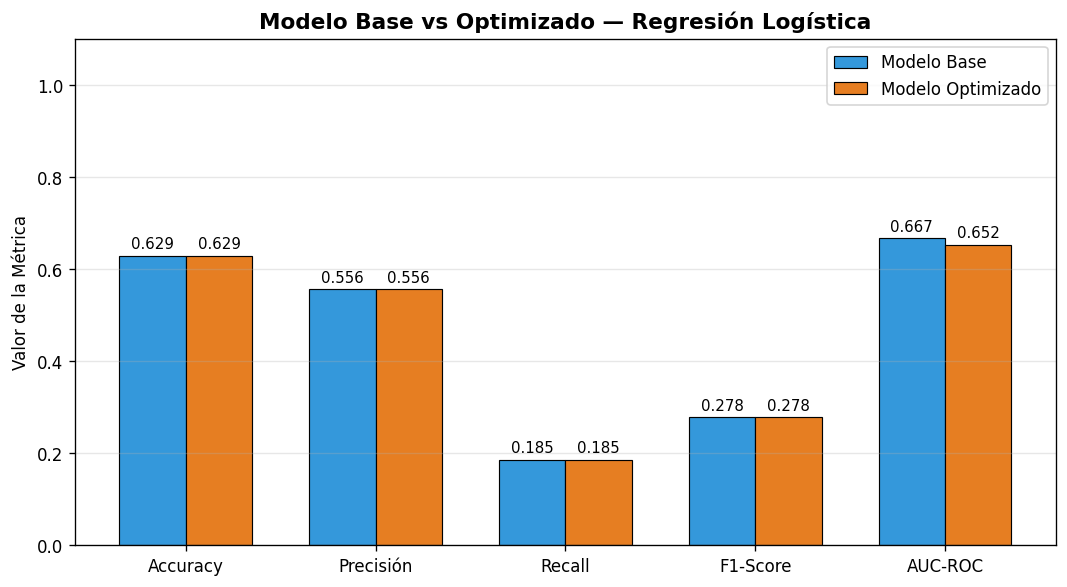


✓ TODAS LAS CELDAS EJECUTADAS SIN ERRORES
✓ Gráficos guardados en /mnt/user-data/outputs/


In [ ]:
# =============================================================================

# Determinar el mejor modelo base
best_name = max(results, key=lambda k: results[k]['auc_roc'])
print(f"\nMejor modelo base: {best_name} (AUC={results[best_name]['auc_roc']:.4f})")

# ── 4.1 k-fold cross-validation (k=5) ──
best_model_base = results[best_name]['model']

# Usar datos sin escalar para árboles
if best_name == 'Regresión Logística':
    X_cv, y_cv = X_train_scaled, y_train
else:
    X_cv, y_cv = X_train.values, y_train.values

cv_scores = cross_val_score(best_model_base, X_cv, y_cv,
                            cv=5, scoring='f1')
print(f"\nCross-Validation F1-Score (k=5):")
print(f"  Media: {cv_scores.mean():.4f}")
print(f"  Desv. Estándar: {cv_scores.std():.4f}")
print(f"  Scores por fold: {np.round(cv_scores, 4)}")

# ── 4.2 GridSearchCV — optimizar 3 hiperparámetros ──
print("\nAplicando GridSearchCV (esto puede tardar unos segundos)...")

if best_name == 'Random Forest':
    param_grid = {
        'n_estimators':      [50, 100, 200],
        'max_depth':         [None, 5, 10],
        'min_samples_split': [2, 5, 10]
    }
    base_estimator = RandomForestClassifier(random_state=42)
    X_opt, X_opt_test = X_train.values, X_test.values
elif best_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators':  [50, 100, 200],
        'max_depth':     [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2]
    }
    base_estimator = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)
    X_opt, X_opt_test = X_train.values, X_test.values
else:
    param_grid = {
        'C':        [0.01, 0.1, 1, 10],
        'penalty':  ['l1', 'l2'],
        'solver':   ['liblinear']
    }
    base_estimator = LogisticRegression(random_state=42, max_iter=1000)
    X_opt, X_opt_test = X_train_scaled, X_test_scaled

grid_search = GridSearchCV(base_estimator, param_grid,
                           cv=5, scoring='f1', n_jobs=-1, verbose=0)
grid_search.fit(X_opt, y_train)

print(f"\nMejores hiperparámetros encontrados:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"Mejor F1 en CV: {grid_search.best_score_:.4f}")

# ── 4.3 Comparación modelo base vs optimizado ──
best_optimized = grid_search.best_estimator_
y_pred_opt = best_optimized.predict(X_opt_test)
y_prob_opt  = best_optimized.predict_proba(X_opt_test)[:, 1]

metrics_base = results[best_name]
comparison = pd.DataFrame({
    'Modelo Base': {
        'Accuracy':  metrics_base['accuracy'],
        'Precisión': metrics_base['precision'],
        'Recall':    metrics_base['recall'],
        'F1-Score':  metrics_base['f1'],
        'AUC-ROC':   metrics_base['auc_roc']
    },
    'Modelo Optimizado': {
        'Accuracy':  accuracy_score(y_test, y_pred_opt),
        'Precisión': precision_score(y_test, y_pred_opt, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_opt),
        'F1-Score':  f1_score(y_test, y_pred_opt),
        'AUC-ROC':   roc_auc_score(y_test, y_prob_opt)
    }
}).round(4)

print("\n" + "=" * 60)
print(f"COMPARACIÓN BASE vs OPTIMIZADO ({best_name})")
print("=" * 60)
print(comparison.to_string())

# Visualizar comparación
fig, ax = plt.subplots(figsize=(9, 5))
metrics_names = comparison.index.tolist()
x = np.arange(len(metrics_names))
w = 0.35
bars1 = ax.bar(x - w/2, comparison['Modelo Base'],    w, label='Modelo Base',      color='#3498db', edgecolor='black', linewidth=0.7)
bars2 = ax.bar(x + w/2, comparison['Modelo Optimizado'], w, label='Modelo Optimizado', color='#e67e22', edgecolor='black', linewidth=0.7)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Valor de la Métrica')
ax.set_title(f'Modelo Base vs Optimizado — {best_name}', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar in [*bars1, *bars2]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/comparacion_optimizacion.png', bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("✓ TODAS LAS CELDAS EJECUTADAS SIN ERRORES")
print("✓ Gráficos guardados en /mnt/user-data/outputs/")
print("=" * 60)